<h1 style="color: #CEDDF4;">DEPI Round 4, MS Data Engineer and AI Track</h1>
<h2 style="color: #CEDDF4;" >Final Project: Gold and Oil Prediction System</h2>
<h3 style="color: #CEDDF4;" > Part (2): Python Code for Machine Learning and Modeling</h3>

<h4 style="color: #CEDDF4;" >1. Import Libraries</h4>

In [65]:
import os
import math
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor

import lightgbm as lgb

import joblib

In [66]:
base_dir = Path.cwd()
#raw data path to contain all raw files gathered either manually, web scraping or APIs
raw_data_dir=base_dir/'raw data'
#cleaned data path, will be separated into two main folders which are: market data (contains the data with daily logs) and macroeconomic data
##cleaned market data
cleaned_market_data_dir=base_dir/'cleaned data'/'market_data'
##cleaned macroeconomic data
cleaned_macro_data_dir=base_dir/'cleaned data'/'macroeconomic_data'
##ai modeling data
ai_data_dir=base_dir/'ai model'

<h4 style="color: #CEDDF4;" >1.1 Data Loading and Processing</h4>

In [67]:
def make_tag(filename):
    tag = filename
    tag = tag.replace('global_', '').replace('usa_', '').replace('egy_', '')
    tag = tag.replace('_prices', '').replace('_price', '').replace('_index', '').replace('_rate', '')
    return tag

In [68]:
#the below function is made to call all the date within specific folder (market / macro) and make final cleaning and sorting methods on it to be using in our master table
def loading(filename, tag, dir):
    df = pd.read_csv(dir / f"{filename}.csv")
    df = df.drop(columns=['id', 'region', 'ticker'], errors='ignore')
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce')
    df = df.rename(columns={c: f"{tag}_{c}" for c in df.columns if c != 'date'})
    df = df.drop_duplicates(subset='date')
    df = df.set_index('date')
    full_dates = pd.date_range(start='2016-01-01', end='2026-03-29', freq='D')
    df = df.reindex(full_dates)
    first_valid = df.first_valid_index()
    if first_valid is not None:
        df.loc[:first_valid] = df.loc[:first_valid].bfill()
    df = df.ffill()
    df = df.reset_index().rename(columns={'index': 'date'})
    return df

In [69]:
#the below is for loop to iterate over all files within cleaned market data 
all_market_df=[]
for filepath in cleaned_market_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_market_data_dir)
    all_market_df.append(new_df)

In [70]:
#the below is a minor tweak to egy_cpi file in macroeconomic data folder which is obtained via data_cleaning.ipynb section 2.1
egy_cpi=pd.read_csv(cleaned_macro_data_dir/'egy_cpi.csv')
egy_cpi=egy_cpi.rename(columns={'year':'date'})
egy_cpi.to_csv(cleaned_macro_data_dir/'egy_cpi.csv',index=False)

In [71]:
#the below is for loop to iterate over all files within cleaned macroeconomic data data 
all_macro_df=[]
for filepath in cleaned_macro_data_dir.glob("*.csv"):
    raw_file_name = filepath.stem
    tag = make_tag(raw_file_name)
    new_df = loading(raw_file_name, tag, cleaned_macro_data_dir)
    all_macro_df.append(new_df)

In [72]:
#get all dataframes from previous steps in one dataframe as reduce function takes only one argument
all_df = all_macro_df + all_market_df
#create the master table and make data column the primary key for merging process
master_table = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), all_df)
master_table = master_table.dropna(axis=1, how='all')

In [73]:
#saving the master table into a csv file to be used in the modeling
master_table.to_csv(ai_data_dir/'master_table.csv',index=False)

In [74]:
df=pd.read_csv(ai_data_dir/'master_table.csv')

In [75]:
df = df.bfill().ffill()

In [76]:
df.to_csv(ai_data_dir/'new_master_table.csv',index=False)

<h4 style="color: #CEDDF4;" >2. Data Reading and Processing</h4>

In [77]:
df=pd.read_csv(ai_data_dir/'new_master_table.csv')

In [78]:
df.shape

(3741, 184)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3741 entries, 0 to 3740
Columns: 184 entries, date to sp500_open_usd
dtypes: float64(175), int64(1), object(8)
memory usage: 5.3+ MB


In [80]:
df.head()

,date,china_cpi_value,china_energy_oil_elec_pct,china_energy_energy_use,china_energy_fuel_imports,china_energy_fuel_exports,china_energy_gas_elec_pct,china_gdp_value_usd,china_ir_value,egypt_energy_oil_elec_pct,...,dowjones_low_usd,dowjones_open_usd,nasdaq_price_usd,nasdaq_high_usd,nasdaq_low_usd,nasdaq_open_usd,sp500_price_usd,sp500_high_usd,sp500_low_usd,sp500_open_usd
0,2016-01-01,101.1,0.167214,2149.20475,12.091734,1.281001,2.749878,1.624100e+13,2.9,15.533161,...,16957.630859,17405.480469,4903.089844,4903.089844,4846.979980,4897.649902,2012.660034,2038.199951,1989.680054,2038.199951
1,2016-01-02,101.1,0.167214,2149.20475,12.091734,1.281001,2.749878,1.624100e+13,2.9,15.533161,...,16957.630859,17405.480469,4903.089844,4903.089844,4846.979980,4897.649902,2012.660034,2038.199951,1989.680054,2038.199951
2,2016-01-03,101.1,0.167214,2149.20475,12.091734,1.281001,2.749878,1.624100e+13,2.9,15.533161,...,16957.630859,17405.480469,4903.089844,4903.089844,4846.979980,4897.649902,2012.660034,2038.199951,1989.680054,2038.199951
3,2016-01-04,101.1,0.167214,2149.20475,12.091734,1.281001,2.749878,1.624100e+13,2.9,15.533161,...,16957.630859,17405.480469,4903.089844,4903.089844,4846.979980,4897.649902,2012.660034,2038.199951,1989.680054,2038.199951
4,2016-01-05,101.1,0.167214,2149.20475,12.091734,1.281001,2.749878,1.624100e+13,2.9,15.533161,...,17038.609375,17147.500000,4891.430176,4926.729980,4872.740234,4917.839844,2016.709961,2021.939941,2004.170044,2013.780029


<h4 style="color: #CEDDF4;" >2.1 Handling data </h4>

In [81]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce')
data = df[df['date'] <= '2025-08-30']
data_clean = data.copy()

for col in data_clean.columns:
    if data_clean[col].dtype == "object":
        data_clean[col] = data_clean[col].astype(str).str.replace('%', '', regex=False)
        data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
data_clean = data_clean.apply(pd.to_numeric, errors='coerce')
data_clean = data_clean.dropna(axis=1, how='all')


C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_5816\1030851805.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_5816\1030851805.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_5816\1030851805.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
C:\Users\Basio_Wolf\AppData\Local\Temp\ipykernel_5816\1030851805.py:8: FutureWarning: errors='ignore

<h4 style="color: #CEDDF4;" >2.2 Data Correlation</h4>

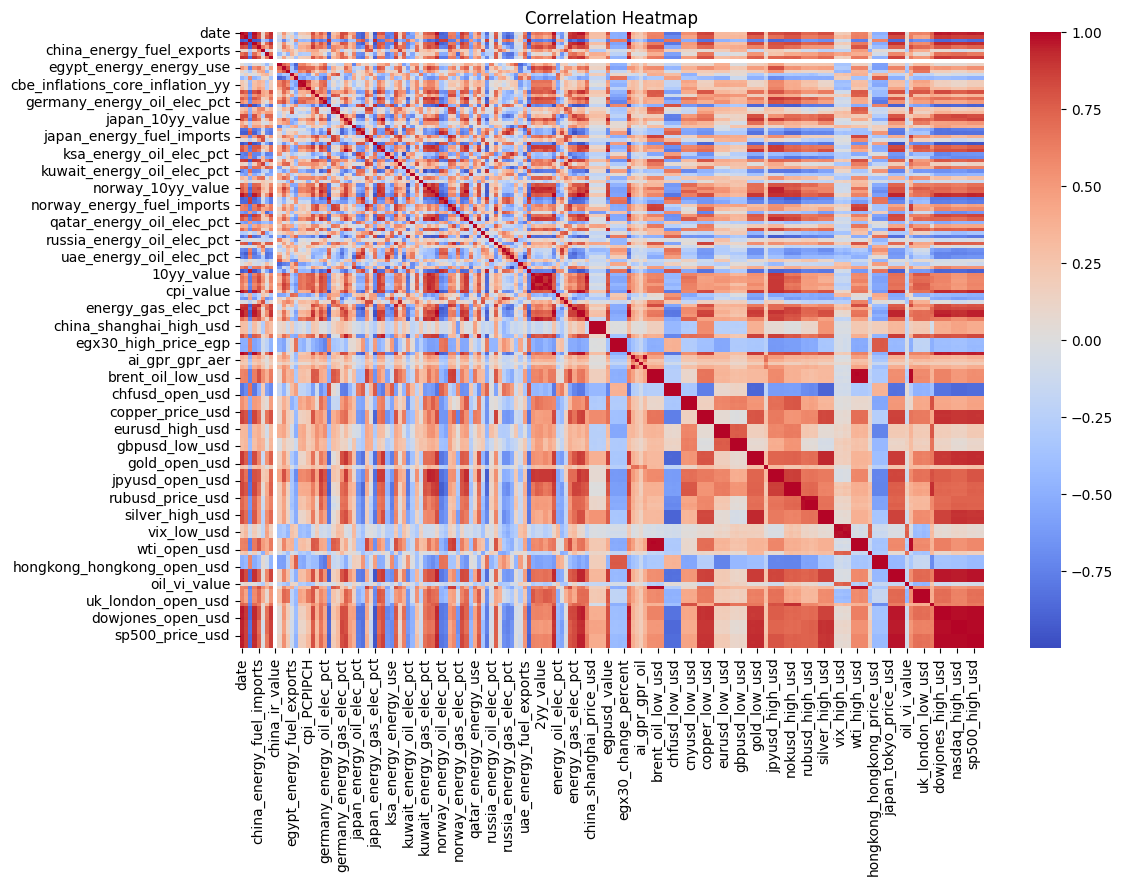

In [82]:
corr = data_clean.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

<h4 style="color: #CEDDF4;" >2.3 Saving Data Correlation</h4>

In [83]:
data_clean.to_csv(ai_data_dir/'stats.csv',index=False)

<h4 style="color: #CEDDF4;" >3. Gold Price Prediction</h4>

<h4 style="color: #CEDDF4;" > 3.1 Setup</h4>

In [84]:
# define target variable
target_col = 'gold_price_usd'
# avoid modifying original dataset
df = df.copy()  

<h4 style="color: #CEDDF4;" > 3.2 Time preprocessing</h4>


In [85]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce') 
df = df.sort_values('date')  

<h4 style="color: #CEDDF4;" > 3.3 Remove leakage features</h4>

In [86]:
leakage_keywords = [
    '_open_', '_high_', '_low_',
    'gpr_event',
    'ai_gpr_Unnamed',
    'gold_price_oz_egp',
    'cbe_inflations_headline_inflation_yy',
    'cbe_inflations_core_inflation_yy'
]
### remove features that leak future info
df = df.drop(columns=[
    c for c in df.columns
    if any(k in c for k in leakage_keywords)
], errors='ignore')  


<h4 style="color: #CEDDF4;" > 3.4 Macro feature engineering</h4>


In [87]:
df['real_rate_us'] = df['usd_fedfunds_value'] - df['cpi_value']  # US real interest rate
df['real_rate_eu'] = df['euro_interest_value'] - df['euro_inflation_value']  # EU real interest rate

df['oil_x_dxy'] = df['brent_oil_price_usd'] * df['dollarindex_value']  # oil-dollar interaction
df['vix_x_dxy'] = df['vix_price_usd'] * df['dollarindex_value']  # volatility-dollar interaction

df['sp500_mom'] = df['sp500_price_usd'].pct_change()  # market momentum

<h4 style="color: #CEDDF4;" > 3.5 Feature engineering</h4>



In [88]:
df['log_price'] = np.log(df[target_col])  # log transformation for stability
df['return'] = df['log_price'].diff()  # compute returns

df['target'] = df['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df['target'] = df['target'].clip(-0.03, 0.03)  # limit extreme values


<h4 style="color: #CEDDF4;" > 3.6 Lag features</h4>


In [89]:
for lag in [1,2,3,5,10,20]:
    df[f'return_lag_{lag}'] = df['return'].shift(lag)  # past returns

df['log_price_lag1'] = df['log_price'].shift(1)  # previous price level

<h4 style="color: #CEDDF4;" > 3.7 Volatility and momentum</h4>


In [90]:
df['vol_7'] = df['return'].rolling(7).std().shift(1)  # short volatility
df['vol_20'] = df['return'].rolling(20).std().shift(1)  # long volatility
df['mom_7'] = df['return'].rolling(7).mean().shift(1)  # short momentum

df['price_trend_7'] = df[target_col].rolling(7).mean().shift(1)  # trend feature

<h4 style="color: #CEDDF4;" > 3.8 Data cleaning</h4>


In [91]:
df = df.dropna()  # remove missing values

<h4 style="color: #CEDDF4;" > 3.9 Feature selection</h4>


In [92]:
features = [c for c in df.columns if c not in ['date', target_col, 'target']]  # model inputs

<h4 style="color: #CEDDF4;" > 3.10 Train/test split</h4>


In [93]:
train = df[df['date'] <= '2025-12-30']  # training period
test = df[(df['date'] > '2025-12-30')]  # testing period

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

<h4 style="color: #CEDDF4;" > 3.11 time series Cross-validation</h4>


In [94]:
tscv = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv.split(X_train)):

    model_cv = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6
    )

    model_cv.fit(X_train.iloc[tr], y_train.iloc[tr])  # train fold model

    pred = model_cv.predict(X_train.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train.iloc[val], pred))  # error
    print("DIR:", np.mean(np.sign(y_train.iloc[val]) == np.sign(pred)))  # direction accuracy


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001366 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9199
[LightGBM] [Info] Number of data points in the train set: 606, number of used features: 128
[LightGBM] [Info] Start training from score 0.000299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

<h4 style="color: #CEDDF4;" > 3.12 Full Model training</h4>


In [95]:
model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002648 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15043
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 129
[LightGBM] [Info] Start training from score 0.000383


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;" > 3.13 Feature selection</h4>


In [96]:
selector = SelectFromModel(model, threshold='median', prefit=True)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

model.fit(X_train_sel, y_train)

C:\Users\Basio_Wolf\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\Basio_Wolf\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14023
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 65
[LightGBM] [Info] Start training from score 0.000383


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;" > 3.14 Prediction (full model)</h4>


In [97]:
pred_returns = model.predict(X_test_sel)

C:\Users\Basio_Wolf\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<h4 style="color: #CEDDF4;" > 3.15 Price Prediction (full model)</h4>


In [98]:
start_price = train[target_col].iloc[-1]

prices = [start_price]

for r in pred_returns:
    prices.append(prices[-1] * np.exp(r))

prices = prices[1:]

test = test.copy()
test['pred_price'] = prices

<h4 style="color: #CEDDF4;" > 3.16 Evaluation (full model)</h4>



In [99]:
mae = mean_absolute_error(test[target_col], test['pred_price'])
direction = np.mean(np.sign(test['target']) == np.sign(pred_returns))

print("Full Model MAE:", mae)
print("Full Model Direction:", direction)


Full Model MAE: 383.6106657289392
Full Model Direction: 0.7386363636363636


<h4 style="color: #CEDDF4;" > 3.17 Top Features Extraction</h4>


In [100]:
importance_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

importance_model.fit(X_train, y_train)

importance = pd.Series(
    importance_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002445 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15043
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 129
[LightGBM] [Info] Start training from score 0.000383


<h4 style="color: #CEDDF4;" > 3.18 Top Features selection</h4>



In [101]:
top_k = 15
top_features = importance.head(top_k).index.tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

<h4 style="color: #CEDDF4;" > 3.19 Top model training</h4>



In [102]:
top_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

top_model.fit(X_train_top, y_train)

pred_top = top_model.predict(X_test_top)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000500 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 15
[LightGBM] [Info] Start training from score 0.000383


<h4 style="color: #CEDDF4;" > 3.20 Price Prediction (top model)</h4>



In [103]:
prices_top = [start_price]

for r in pred_top:
    prices_top.append(prices_top[-1] * np.exp(r))

prices_top = prices_top[1:]

test['pred_price_top'] = prices_top

<h4 style="color: #CEDDF4;" > 3.21 Evaluation (top model)</h4>



In [104]:
mae_top = mean_absolute_error(test[target_col], test['pred_price_top'])
direction_top = np.mean(np.sign(test['target']) == np.sign(pred_top))

print("Top Features Model MAE:", mae_top)
print("Top Features Model Direction:", direction_top)

Top Features Model MAE: 112.75224422545278
Top Features Model Direction: 0.7840909090909091


<h4 style="color: #CEDDF4;" > 3.22 Model Comparison Using Visualizations</h4>

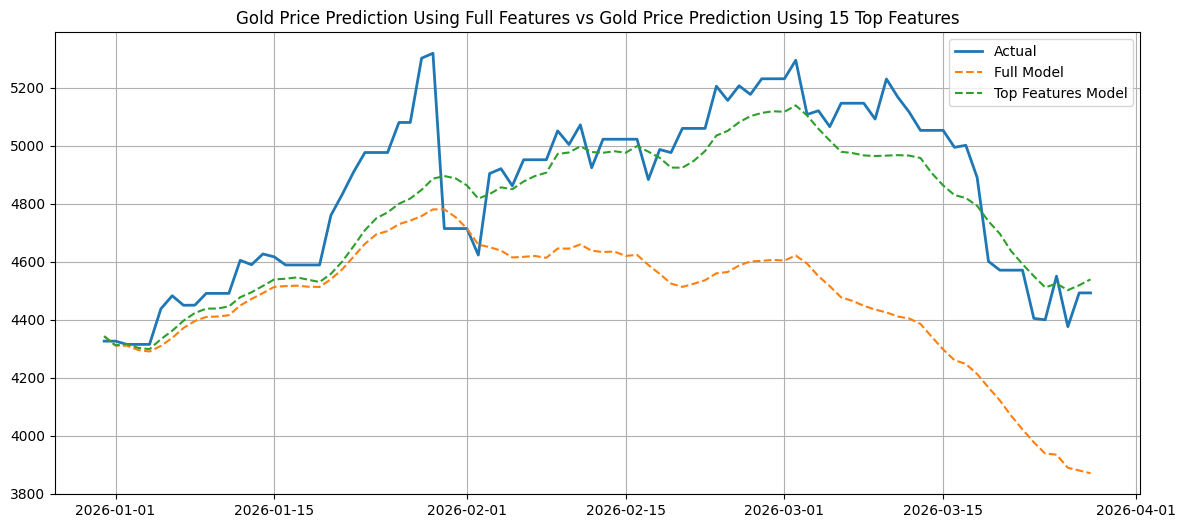

In [105]:
plt.figure(figsize=(14,6))

plt.plot(test['date'], test[target_col], label='Actual', linewidth=2)
plt.plot(test['date'], test['pred_price'], label='Full Model', linestyle='--')
plt.plot(test['date'], test['pred_price_top'], label='Top Features Model', linestyle='--')

plt.legend()
plt.title("Gold Price Prediction Using Full Features vs Gold Price Prediction Using 15 Top Features")
plt.grid()
plt.show()

<h4 style="color: #CEDDF4;" > 3.23 GoldPrice Prediction (tomorrow)</h4>



In [ ]:
latest_top = X_test_top.iloc[-1:]

pred_return_tomorrow = top_model.predict(latest_top)[0]

last_log_price = np.log(train[target_col].iloc[-1])

pred_price_tomorrow = np.exp(last_log_price + pred_return_tomorrow)

print("Predicted Gold Price Tomorrow :", pred_price_tomorrow)

Predicted Price Tomorrow : 4389.731517998451


<h4 style="color: #CEDDF4;" > 4. OIL PRICE PREDICTION</h4>

<h4 style="color: #CEDDF4;" >4.1 Data Reading</h4>



In [107]:
df = pd.read_csv(ai_data_dir/'new_master_table.csv')

<h4 style="color: #CEDDF4;" > 4.2 Setup</h4>

In [108]:
target_col = 'brent_oil_price_usd'
df = df.copy()

<h4 style="color: #CEDDF4;" > 4.3 Time preprocessing</h4>

In [109]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date')

<h4 style="color: #CEDDF4;" > 4.4 Leakage removal</h4>

In [110]:
leakage_keywords = [
    '_open_', '_high_', '_low_',
    'gpr_event',
    'ai_gpr_Unnamed',
    'gold_price_oz_egp',
    'cbe_inflations_headline_inflation_yy',
    'cbe_inflations_core_inflation_yy'
]

leakage_exact = [
    'brent_oil_open_usd',
    'brent_oil_high_usd',
    'brent_oil_low_usd'
]

df = df.drop(columns=[
    c for c in df.columns
    if any(k in c for k in leakage_keywords) or c in leakage_exact
], errors='ignore')

<h4 style="color: #CEDDF4;" > 4.5 Feature Engineering</h4>

In [111]:
df['net_energy_imports'] = df['energy_fuel_imports'] - df['energy_fuel_exports']
df['opec_pressure'] = df['opec_basket_value'] / df['brent_oil_price_usd']
df['geo_risk_oil'] = df['ai_gpr_gpr_oil']
df['oil_vol_x_vix'] = df['oil_vi_value'] * df['vix_price_usd']
df['oil_sp500'] = df['brent_oil_price_usd'] / df['sp500_price_usd']
df['oil_x_dxy'] = df['brent_oil_price_usd'] * df['dollarindex_value']
df['copper_oil_ratio'] = df['copper_price_usd'] / df['brent_oil_price_usd']
df['wti_brent_spread'] = df['wti_price_usd'] - df['brent_oil_price_usd']


<h4 style="color: #CEDDF4;" > 4.6 Target engineering</h4>

In [112]:
df['log_price'] = np.log(df[target_col])
df['return'] = df['log_price'].diff()

df['target'] = df['return'].rolling(5).mean().shift(-1)
df['target'] = df['target'].clip(-0.04, 0.04)


<h4 style="color: #CEDDF4;" > 4.7 Lag features</h4>

In [113]:
for lag in [1,2,3,5,10,20]:
    df[f'return_lag_{lag}'] = df['return'].shift(lag)

df['log_price_lag1'] = df['log_price'].shift(1)


<h4 style="color: #CEDDF4;" > 4.8 Volatility and momentum </h4>

In [114]:
df['vol_7'] = df['return'].rolling(7).std().shift(1)
df['vol_20'] = df['return'].rolling(20).std().shift(1)
df['mom_7'] = df['return'].rolling(7).mean().shift(1)
df['price_trend_7'] = df[target_col].rolling(7).mean().shift(1)

<h4 style="color: #CEDDF4;" > 4.9 Data cleaning </h4>

In [115]:
df = df.dropna()

<h4 style="color: #CEDDF4;" > 4.10 Feature list </h4>

In [116]:
features = [c for c in df.columns if c not in ['date', target_col, 'target']]

<h4 style="color: #CEDDF4;" > 4.11 Train-test split</h4>

In [117]:
train = df[df['date'] <= '2025-12-30']
test = df[(df['date'] > '2025-12-30')]

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']


<h4 style="color: #CEDDF4;" > 4.12 time series Cross-validation</h4>

In [118]:
tscv = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv.split(X_train)):
    model_cv = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6
    )

    model_cv.fit(X_train.iloc[tr], y_train.iloc[tr])
    pred = model_cv.predict(X_train.iloc[val])

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train.iloc[val], pred))
    print("DIR:", np.mean(np.sign(y_train.iloc[val]) == np.sign(pred)))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001483 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9944
[LightGBM] [Info] Number of data points in the train set: 606, number of used features: 131
[LightGBM] [Info] Start training from score 0.001027
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

<h4 style="color: #CEDDF4;" > 4.13 Base model for importance</h4>

In [119]:
base_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

base_model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002888 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15868
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 132
[LightGBM] [Info] Start training from score 0.000217


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;" > 4.14 Feature importance extraction </h4>

In [120]:
importance = pd.Series(
    base_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)


<h4 style="color: #CEDDF4;" > 4.15 Select top features </h4>

In [121]:
top_features = importance.head(15).index.tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]


<h4 style="color: #CEDDF4;" > 4.16 Train full model (all features) </h4>

In [122]:
model_full = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_full.fit(X_train, y_train)
pred_full = model_full.predict(X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005863 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15868
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 132
[LightGBM] [Info] Start training from score 0.000217


<h4 style="color: #CEDDF4;" > 4.17 Train top features model </h4>

In [123]:
model_top = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_top.fit(X_train_top, y_train)
pred_top = model_top.predict(X_test_top)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 3631, number of used features: 15
[LightGBM] [Info] Start training from score 0.000217


<h4 style="color: #CEDDF4;" > 4.18 Price reconstruction </h4>

In [124]:
start_price = train[target_col].iloc[-1]

prices_full = [start_price]
for r in pred_full:
    prices_full.append(prices_full[-1] * np.exp(r))
prices_full = prices_full[1:]

prices_top = [start_price]
for r in pred_top:
    prices_top.append(prices_top[-1] * np.exp(r))
prices_top = prices_top[1:]

test = test.copy()
test['pred_price_full'] = prices_full
test['pred_price_top'] = prices_top


<h4 style="color: #CEDDF4;" > 4.19 Evaluation</h4>

In [125]:
mae_full = mean_absolute_error(test[target_col], test['pred_price_full'])
dir_full = np.mean(np.sign(test['target']) == np.sign(pred_full))

mae_top = mean_absolute_error(test[target_col], test['pred_price_top'])
dir_top = np.mean(np.sign(test['target']) == np.sign(pred_top))

print("Full Model MAE:", mae_full)
print("Full Model Direction:", dir_full)

print("Top Features MAE:", mae_top)
print("Top Features Direction:", dir_top)


Full Model MAE: 8.779991751190819
Full Model Direction: 0.8181818181818182
Top Features MAE: 2.5391518837300313
Top Features Direction: 0.8295454545454546


<h4 style="color: #CEDDF4;" > 4.20 Visualization </h4>

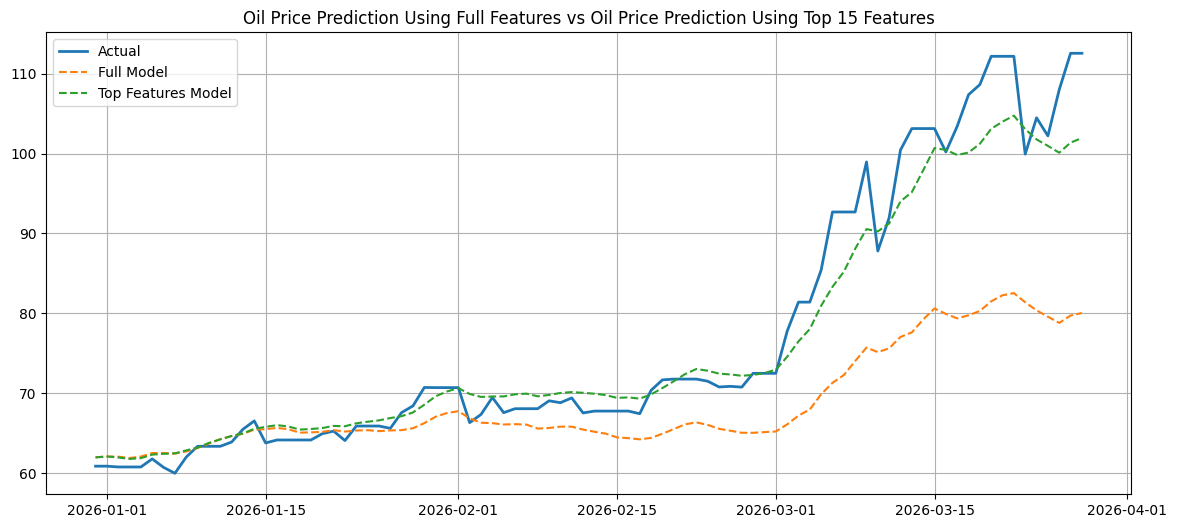

In [128]:
plt.figure(figsize=(14,6))
plt.plot(test['date'], test[target_col], label='Actual', linewidth=2)
plt.plot(test['date'], test['pred_price_full'], label='Full Model', linestyle='--')
plt.plot(test['date'], test['pred_price_top'], label='Top Features Model', linestyle='--')

plt.legend()
plt.title("Oil Price Prediction Using Full Features vs Oil Price Prediction Using Top 15 Features")
plt.grid()
plt.show()

<h4 style="color: #CEDDF4;" > 4.21 Oil price prediction </h4>

In [127]:
# get latest available row from full dataset (not just test)
latest_row = df.iloc[-1:]

# build features exactly like training
latest_features = latest_row[top_features]

# predict next-day return
pred_return_tomorrow = model_top.predict(latest_features)[0]

# get last known price
last_price = latest_row[target_col].values[0]

# convert return to price
pred_price_tomorrow = last_price * np.exp(pred_return_tomorrow)

print("Predicted Brent Oil Price Tomorrow:", pred_price_tomorrow)

Predicted Brent Oil Price Tomorrow: 113.21372548743028
